In [1]:
!pip install datasets -q

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

label_names = dataset["train"].features["label"].names

print(label_names)
train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training examples:", X_train_vec.shape[0])
print("Features:", X_train_vec.shape[1])

Training examples: 16000
Features: 5000


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model training complete.")

Model training complete.


Test Accuracy: 89.15%
              precision    recall  f1-score   support

     sadness       0.91      0.95      0.93       581
         joy       0.87      0.96      0.91       695
        love       0.85      0.69      0.76       159
       anger       0.92      0.83      0.87       275
        fear       0.90      0.85      0.87       224
    surprise       0.97      0.53      0.69        66

    accuracy                           0.89      2000
   macro avg       0.90      0.80      0.84      2000
weighted avg       0.89      0.89      0.89      2000



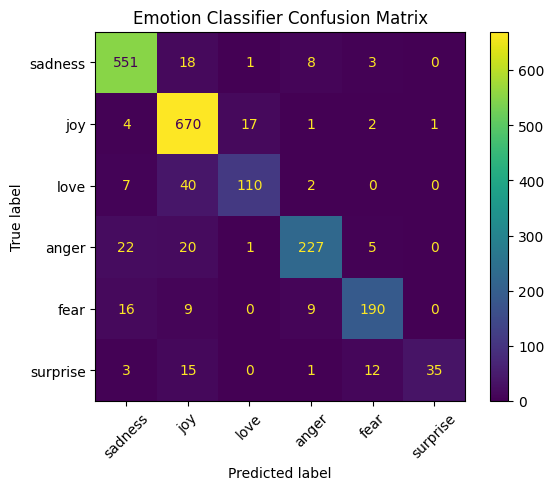

I feel amazing today and everything seems beautiful.
Predicted emotion: joy

I am scared that something bad might happen.
Predicted emotion: fear

I miss them so much.
Predicted emotion: sadness

This is the best day ever.
Predicted emotion: joy

The sky burned red and the birds sang like heaven was awake.
Predicted emotion: sadness



In [4]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_names
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_names,
    xticks_rotation=45
)

plt.title("Emotion Classifier Confusion Matrix")
plt.show()


def predict_emotion(sentence):
    sentence_vec = vectorizer.transform([sentence])
    prediction = model.predict(sentence_vec)[0]
    emotion = label_names[prediction]
    return emotion


examples = [
    "I feel amazing today and everything seems beautiful.",
    "I am scared that something bad might happen.",
    "I miss them so much.",
    "This is the best day ever.",
    "The sky burned red and the birds sang like heaven was awake."
]

for sentence in examples:
    print(sentence)
    print("Predicted emotion:", predict_emotion(sentence))
    print()

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_box = widgets.Textarea(
    value="",
    placeholder="Type a sentence here...",
    description="Text:",
    layout=widgets.Layout(width="600px", height="100px")
)

button = widgets.Button(
    description="Predict Emotion",
    button_style="success"
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        sentence = text_box.value

        if sentence.strip() == "":
            print("Please type a sentence first.")
        else:
            emotion = predict_emotion(sentence)
            print("Predicted emotion:", emotion)

button.on_click(on_button_click)

display(text_box, button, output)

Textarea(value='', description='Text:', layout=Layout(height='100px', width='600px'), placeholder='Type a sent…

Button(button_style='success', description='Predict Emotion', style=ButtonStyle())

Output()